# AT5 - Análise de dados do Titanic

## 1. Import de bibliotecas

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Carregamento de arquivo com tratamento de erro

In [4]:
try:
    train = pd.read_csv('train.csv')
    print("Arquivo carregado com sucesso!")
except FileNotFoundError:
    print("Erro: arquivo train.csv não encontrado.")

Arquivo carregado com sucesso!


## 3. Quantidade de linhas e colunas

In [18]:
# print(f"Quantidades de linhas e colunas:{train.shape}")
print(f"O dataset possui {train.shape[0]} linhas e {train.shape[1]} colunas.")

O dataset possui 891 linhas e 12 colunas.


Explicação
- `shape` retorna uma tupla;
- O primeiro valor representa as linhas;
- O segundo valor representa as colunas.

## 4. Tipo de dado de cada variável

In [20]:
print("Tipos de dados:\n")
print(train.dtypes)

Tipos de dados:

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


- `int64`   - números inteiros
- `float64` - números decimais
- `object`  - textos/categorias

## 5. Resumo estatístico das variáveis

In [24]:
print("Resumo estatistico das variáveis:")
display(train.describe(include='all'))

Resumo estatistico das variáveis:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,B96 B98,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


Explicação: O resumo estatístico mostra:
- média
- desvio padrão
- mínimo
- máximo
- quartis

Essas informações ajundam a entender a distribuição de dados.

## 6. Tabela de frequência da variável survival e gráfico para "Survived"


-- Análise de sobrevivência --
Tabela de frequência (0 = Não, 1 = Sim):
Survived
0    549
1    342
Name: count, dtype: int64


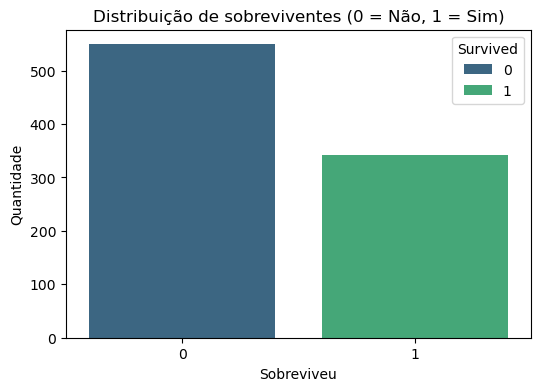

In [56]:
print("\n-- Análise de sobrevivência --")
freq_survival = train['Survived'].value_counts()
freq_relativa = train['Survived'].value_counts(normalize=True) * 100
print("Tabela de frequência (0 = Não, 1 = Sim):")
print(freq_survival)

plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=train, hue='Survived', palette='viridis')
plt.title('Distribuição de sobreviventes (0 = Não, 1 = Sim)')
plt.xlabel("Sobreviveu")
plt.ylabel("Quantidade")
plt.show()

### Explicação do gráfico

O gráfico de barras (countplot) foi escolhido por ser uma variável categórica nominal.
Ele permite comparar visualmente a frequência absoluta de cada categoria de forma clara.

## 7. Quantas pessoas sobreviveram? Qual a classe mais frequente?

In [49]:
sobreviventes = freq_survival[1]
train['Classe_nome'] = train['Pclass'].map({1: '1ª Classe', 2: '2ª Classe', 3: '3ª Classe'})[0]
classe_frequente_nome = train['Classe_nome'].mode()[0]
print(f"Total de sobreviventes: {sobreviventes}")
print(f"A classe mais comum a bordo era a: {classe_frequente_nome}")

Total de sobreviventes: 342
A classe mais comum a bordo era a: 3ª Classe


## 8. Relação entre "Sex" e "Survival"


-- Relação Sexo x Sobreviventes --
Survived    0    1
Sex               
female     81  233
male      468  109


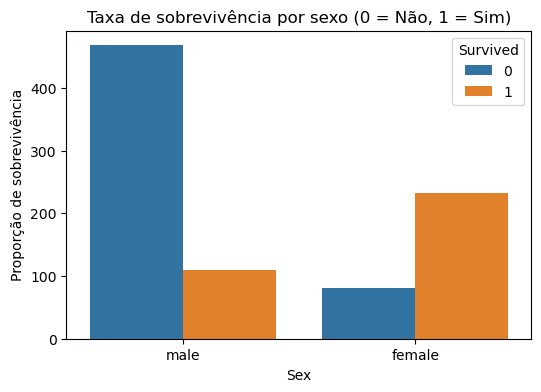

In [57]:
print("\n-- Relação Sexo x Sobreviventes --")
tab_sex_survived = pd.crosstab(train['Sex'], train['Survived'])
print(tab_sex_survived)

plt.figure(figsize=(6,4))
sns.countplot(x='Sex', hue='Survived', data=train)
plt.title('Taxa de sobrevivência por sexo (0 = Não, 1 = Sim)')
plt.ylabel('Proporção de sobrevivência')
plt.show()

### Mulheres sobreviveram mais que os homens?

In [45]:
taxa_mulheres = train[train['Sex'] == 'female']['Survived'].mean()
taxa_homens = train[train['Sex'] == 'male']['Survived'].mean()
print(f"Taxa de sobrevivência - Mulheres: {taxa_mulheres:.2%}, Homens: {taxa_homens:.2%}")

Taxa de sobrevivência - Mulheres: 74.20%, Homens: 18.89%


Sim, as mulheres tiveram uma taxa de sobrevivência significativamente maior.

## 10. Distribuição das idades


--- Distribuição de idades ---


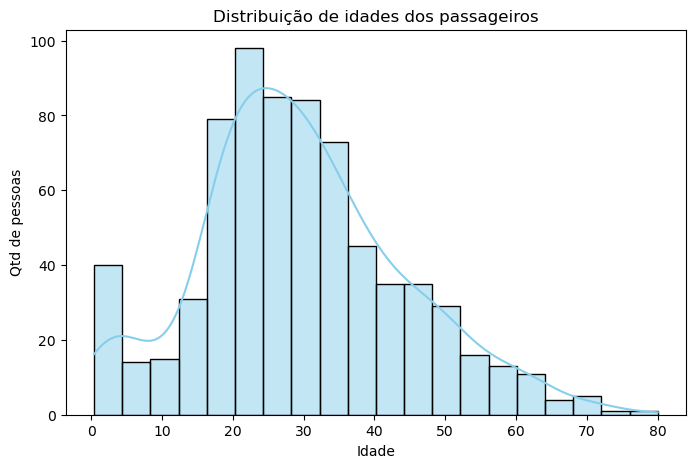

In [53]:
print("\n--- Distribuição de idades ---")
plt.figure(figsize=(8,5))
sns.histplot(train['Age'].dropna(), kde=True, color='skyblue')
plt.title('Distribuição de idades dos passageiros')
plt.xlabel('Idade')
plt.ylabel('Qtd de pessoas')
plt.show()

### Análise da distribuição

A distribuição parece ligeiramente assimétrica à direita - possuindo calda longa para idades maiores. A maioria dos passageiros eram jovens - concentrado entre 20 e 40 anos -, com uma presença notável de crianças pequenas.
